In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import diplib as dip
from tifffile import tifffile as tiff

# ── Load the 3D image ──────────────────────────────────────────────────────────
path = "<PATH_TO_YOUR_TIFF_FILE>"  # adjust if needed
image_stack = tiff.imread(path)

print(f"Shape (Z, Y, X): {image_stack.shape}")
print(f"Number of slices (Z): {image_stack.shape[0]}")

# ── Aspect ratio ──────────────────────────────────────────────────────────────
# Voxel size is typically stored in the TIFF metadata
# Common for CLSM: XY pixel size ~0.1 µm, Z step ~0.3 µm → aspect ratio 1:1:3
# You can read metadata with tifffile:
with tiff.TiffFile(path) as tf:
    tags = tf.pages[0].tags
    # Try to extract XResolution, YResolution if present
    for tag in tags.values():
        print(tag.name, tag.value)

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org
Shape (Z, Y, X): (16, 140, 160)
Number of slices (Z): 16
NewSubfileType 0
ImageWidth 160
ImageLength 140
BitsPerSample 8
PhotometricInterpretation 3
ImageDescription ImageJ=1.53c
images=16
slices=16
loop=false
min=8.0
max=255.0
StripOffsets (3377,)
SamplesPerPixel 1
RowsPerStrip 140
StripByteCounts (22400,)
ColorMap [[    0   256   512   768  1024  1280  1536  1792  2048  2304  2560  2816
   3072  3328  3584  3840  4096  4352  4608  4864  5120  5376  5632  5888
   6144  6400  6656  6912  7168  7424  7680  7936  8192  8448  8704  8960
   9216  9472  9728  9984 10240 10496 10752 11008 11264 11520 11776 12032
  12288 12544 12800 13056 13312 13568 13824 14080 14336 14592 14848 15104
  15360 15616 15872 16128 16384 16640 16896 17152 17408 17664 17920 18176
  18432 18688 18944 19200 19456 19712 19968 20224 20480 20736 20992 21248
  21504 21760 22016 22272 22528 22784 23040 

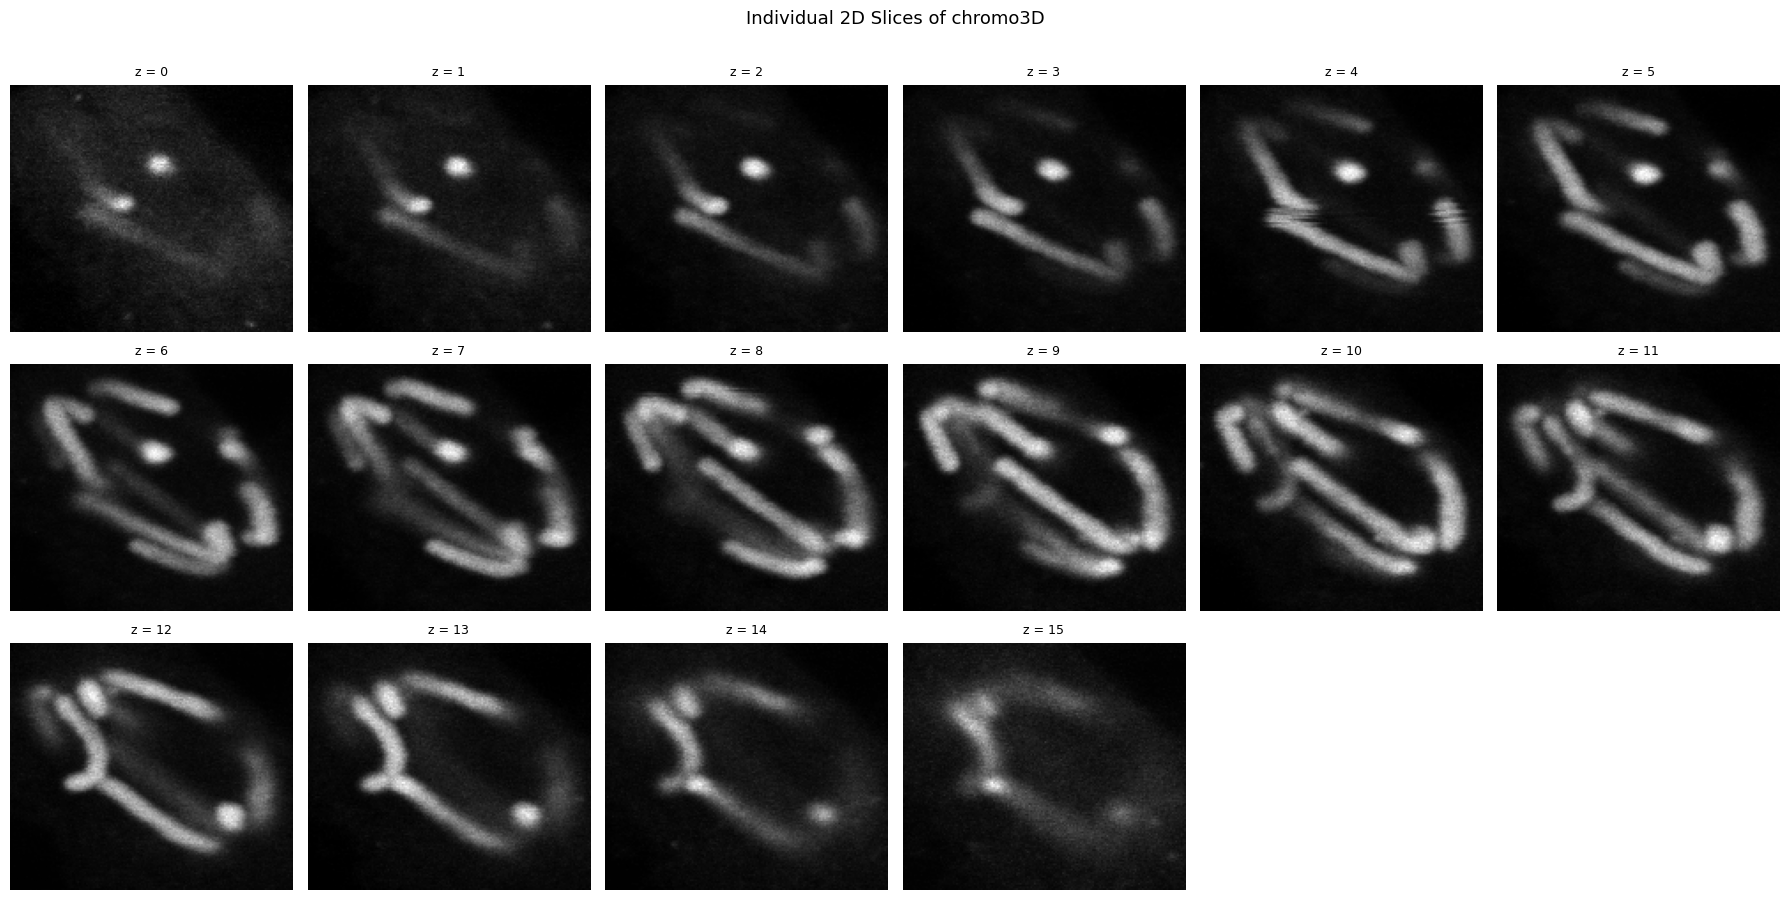

Displayed 16 slices (every 1 slice(s))


In [3]:
# ── Part 1.2 - Display individual 2D slices ───────────────────────────────────
def display_slices(image_stack, step=1, cmap='gray'):
    """
    Displays individual 2D slices from a 3D TIFF image stack.
    step: show every nth slice to avoid too many plots
    """
    n_slices = image_stack.shape[0]
    slices_to_show = range(0, n_slices, step)
    n = len(slices_to_show)

    cols = 6
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for i, z in enumerate(slices_to_show):
        axes[i].imshow(image_stack[z], cmap=cmap)
        axes[i].set_title(f"z = {z}", fontsize=9)
        axes[i].axis('off')

    # hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Individual 2D Slices of chromo3D", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("slices_overview.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Displayed {n} slices (every {step} slice(s))")

display_slices(image_stack, step=1)

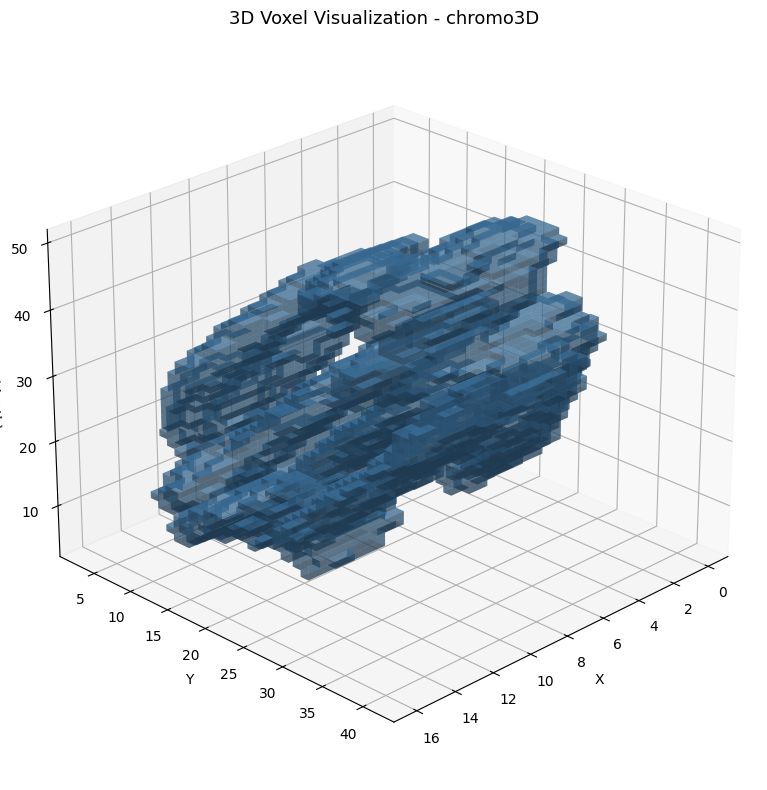

In [4]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# ── Otsu threshold (inline, no dependencies) ──────────────────────────────────
def otsu_threshold(image):
    hist, bin_edges = np.histogram(image.flatten(), bins=256)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total = hist.sum()
    best_thresh, best_variance = 0, 0
    weight_bg, sum_bg = 0, 0
    total_sum = np.sum(bin_centers * hist)
    for i in range(len(hist)):
        weight_bg += hist[i]
        if weight_bg == 0: continue
        weight_fg = total - weight_bg
        if weight_fg == 0: break
        sum_bg += bin_centers[i] * hist[i]
        mean_bg = sum_bg / weight_bg
        mean_fg = (total_sum - sum_bg) / weight_fg
        between_variance = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if between_variance > best_variance:
            best_variance = between_variance
            best_thresh = bin_centers[i]
    return best_thresh

# ── Build binary ───────────────────────────────────────────────────────────────
threshold_value = otsu_threshold(image_stack)
binary_np = (image_stack > threshold_value).astype(np.uint8)

# ── 3D voxel plot ─────────────────────────────────────────────────────────────
small = binary_np[:, ::3, ::3]  # downsample XY only, keep all 16 z-slices

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.voxels(small > 0, facecolors='steelblue', edgecolor=None, alpha=0.5)
ax.set_title("3D Voxel Visualization - chromo3D", fontsize=13)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z (depth)")
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.savefig("voxel_3d.png", dpi=150, bbox_inches='tight')
plt.show()

## Part 2 Thresholding 

First, plot histograms, then try 3 different methods, then compare them and determine the best one.

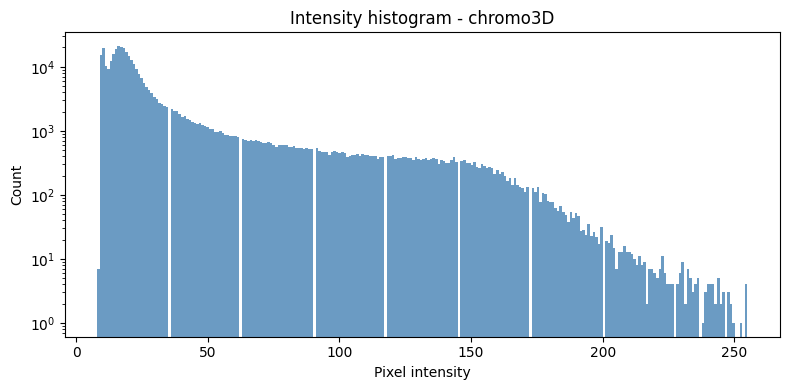

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Plot the histogram to understand the intensity distribution ─────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(image_stack.flatten(), bins=256, color='steelblue', alpha=0.8)
ax.set_title("Intensity histogram - chromo3D")
ax.set_xlabel("Pixel intensity")
ax.set_ylabel("Count")
ax.set_yscale('log')  # log scale reveals low-intensity background better
plt.tight_layout()
plt.savefig("histogram.png", dpi=150)
plt.show()

In [6]:
# ── 2. Implement 3 methods and compare ────────────────────────────────────────

# Method A: Otsu (maximises between-class variance)
def otsu_threshold(image):
    hist, bin_edges = np.histogram(image.flatten(), bins=256)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total = hist.sum()
    best_thresh, best_variance = 0, 0
    weight_bg, sum_bg = 0, 0
    total_sum = np.sum(bin_centers * hist)
    for i in range(len(hist)):
        weight_bg += hist[i]
        if weight_bg == 0: continue
        weight_fg = total - weight_bg
        if weight_fg == 0: break
        sum_bg += bin_centers[i] * hist[i]
        mean_bg = sum_bg / weight_bg
        mean_fg = (total_sum - sum_bg) / weight_fg
        between_variance = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if between_variance > best_variance:
            best_variance = between_variance
            best_thresh = bin_centers[i]
    return best_thresh

# Method B: Isodata (iterative mean of foreground + background)
def isodata_threshold(image, t0=None):
    flat = image.flatten().astype(float)
    t = t0 if t0 is not None else flat.mean()
    for _ in range(1000):
        mL = flat[flat <= t].mean()
        mH = flat[flat > t].mean()
        t_new = (mL + mH) / 2
        if abs(t - t_new) < 0.5:
            break
        t = t_new
    return t

# Method C: Mean (simple global mean - useful baseline)
mean_thresh = image_stack.mean()

t_otsu    = otsu_threshold(image_stack)
t_isodata = isodata_threshold(image_stack)
t_mean    = mean_thresh

print(f"Otsu threshold:    {t_otsu:.1f}")
print(f"Isodata threshold: {t_isodata:.1f}")
print(f"Mean threshold:    {t_mean:.1f}")

Otsu threshold:    67.3
Isodata threshold: 66.8
Mean threshold:    32.9


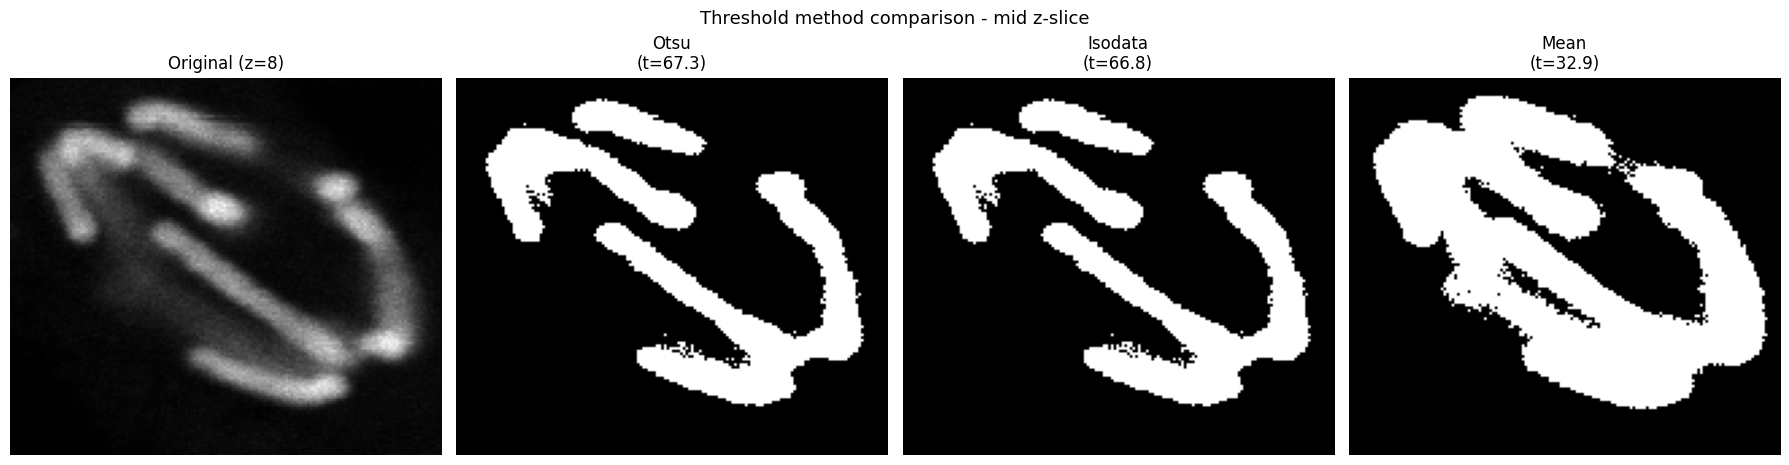

In [7]:
# ── 3. Visual comparison on a mid-slice ───────────────────────────────────────
mid = image_stack.shape[0] // 2

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image_stack[mid], cmap='gray')
axes[0].set_title(f"Original (z={mid})")

for ax, (t, label) in zip(axes[1:], [
    (t_otsu,    f"Otsu\n(t={t_otsu:.1f})"),
    (t_isodata, f"Isodata\n(t={t_isodata:.1f})"),
    (t_mean,    f"Mean\n(t={t_mean:.1f})"),
]):
    binary = (image_stack[mid] > t).astype(np.uint8) * 255
    ax.imshow(binary, cmap='gray')
    ax.set_title(label)

for ax in axes:
    ax.axis('off')

plt.suptitle("Threshold method comparison - mid z-slice", fontsize=13)
plt.tight_layout()
plt.savefig("threshold_comparison.png", dpi=150)
plt.show()

Otsu is performing the best, so we go with Otsu from now on. Now, for the question what is the best value:

Peak variance at intensity: 67.3


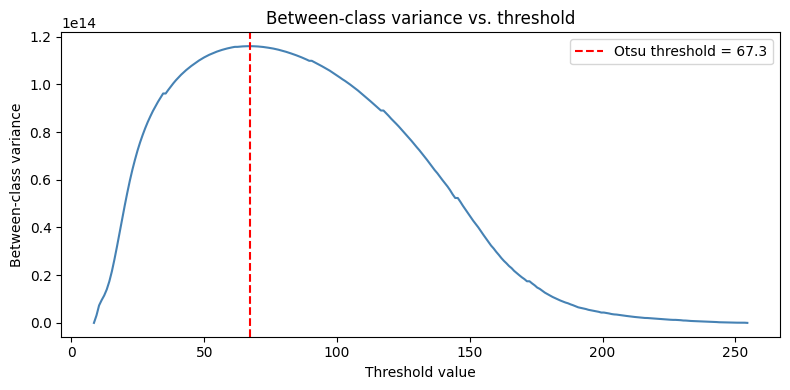

In [8]:
# Plot the between-class variance curve to show WHY 67.3 was chosen
hist, bin_edges = np.histogram(image_stack.flatten(), bins=256)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

total = hist.sum()
total_sum = np.sum(bin_centers * hist)

variances = []
weight_bg, sum_bg = 0, 0

for i in range(len(hist)):
    weight_bg += hist[i]
    weight_fg = total - weight_bg
    if weight_bg == 0 or weight_fg == 0:
        variances.append(0)
        continue
    sum_bg += bin_centers[i] * hist[i]
    mean_bg = sum_bg / weight_bg
    mean_fg = (total_sum - sum_bg) / weight_fg
    variances.append(weight_bg * weight_fg * (mean_bg - mean_fg) ** 2)

best_idx = np.argmax(variances)
print(f"Peak variance at intensity: {bin_centers[best_idx]:.1f}")

plt.figure(figsize=(8, 4))
plt.plot(bin_centers, variances, color='steelblue')
plt.axvline(bin_centers[best_idx], color='red', linestyle='--',
            label=f"Otsu threshold = {bin_centers[best_idx]:.1f}")
plt.title("Between-class variance vs. threshold")
plt.xlabel("Threshold value")
plt.ylabel("Between-class variance")
plt.legend()
plt.tight_layout()
plt.savefig("otsu_variance_curve.png", dpi=150)
plt.show()

### Depth cueing algorithm 


In [9]:
# ── Depth Cueing Algorithm ─────────────────────────────────────────────────────
def depth_cueing(binary_stack):
    """
    Depth cueing algorithm:
      1. Take a thresholded (binary) 3D image of shape (Z, Y, X)
      2. For each z-plane, compute a linear brightness weight:
            weight(z) = (z + 1) / Z
         where z=0 is the deepest plane (weight near 0, darkest)
         and z=Z-1 is the shallowest plane (weight=1.0, brightest)
      3. Multiply each binary plane by its weight, scaling the
         foreground voxels from near-black to white across depth
      4. Normalise the result to the full 0-255 uint8 range
    """
    n_z = binary_stack.shape[0]
    depth_cued = np.zeros_like(binary_stack, dtype=np.float32)

    for z in range(n_z):
        weight = (z + 1) / n_z  # linear ramp: 1/n_z → 1.0
        depth_cued[z] = binary_stack[z].astype(np.float32) * weight

    # Normalise to 0-255
    depth_cued = (depth_cued / depth_cued.max() * 255).astype(np.uint8)
    return depth_cued

# ── Apply ──────────────────────────────────────────────────────────────────────
binary_np = (image_stack > t_otsu).astype(np.uint8)
depth_cued_image = depth_cueing(binary_np)

tiff.imwrite("chromo3D_binary.tiff",     (binary_np * 255).astype(np.uint8))
tiff.imwrite("chromo3D_depth_cued.tiff", depth_cued_image)
print("Saved: chromo3D_binary.tiff and chromo3D_depth_cued.tiff")

Saved: chromo3D_binary.tiff and chromo3D_depth_cued.tiff


Need to save the depth cueing as tiff for part 3


In [ ]:
from tifffile import tifffile as tiff
import numpy as np

# ── Rebuild binary cleanly ─────────────────────────────────────────────────────
threshold_value = otsu_threshold(image_stack)
binary_np = (image_stack > threshold_value).astype(np.uint8) * 255

# ── Depth cueing ───────────────────────────────────────────────────────────────
def depth_cueing(binary_stack):
    n_z = binary_stack.shape[0]
    depth_cued = np.zeros_like(binary_stack, dtype=np.float32)
    for z in range(n_z):
        weight = (z + 1) / n_z
        depth_cued[z] = binary_stack[z].astype(np.float32) * weight
    depth_cued = (depth_cued / depth_cued.max() * 255).astype(np.uint8)
    return depth_cued

depth_cued_image = depth_cueing(binary_np)

# ── Save both as TIFF ──────────────────────────────────────────────────────────
save_path = "<PATH_TO_SAVE_DIRECTORY>"  # adjust if needed

tiff.imwrite(save_path + "chromo3D_binary.tiff", binary_np)
tiff.imwrite(save_path + "chromo3D_depth_cued.tiff", depth_cued_image)

print(f"Binary shape: {binary_np.shape}, dtype: {binary_np.dtype}")
print(f"Depth cued shape: {depth_cued_image.shape}, dtype: {depth_cued_image.dtype}")
print("Both files saved successfully!")

Binary shape: (16, 140, 160), dtype: uint8
Depth cued shape: (16, 140, 160), dtype: uint8
Both files saved successfully!


In [13]:
print(f"Depth cued min: {depth_cued_image.min()}")
print(f"Depth cued max: {depth_cued_image.max()}")
print(f"Depth cued mean: {depth_cued_image.mean():.1f}")
print(f"Depth cued non-zero min: {depth_cued_image[depth_cued_image > 0].min()}")

Depth cued min: 0
Depth cued max: 255
Depth cued mean: 18.2
Depth cued non-zero min: 15


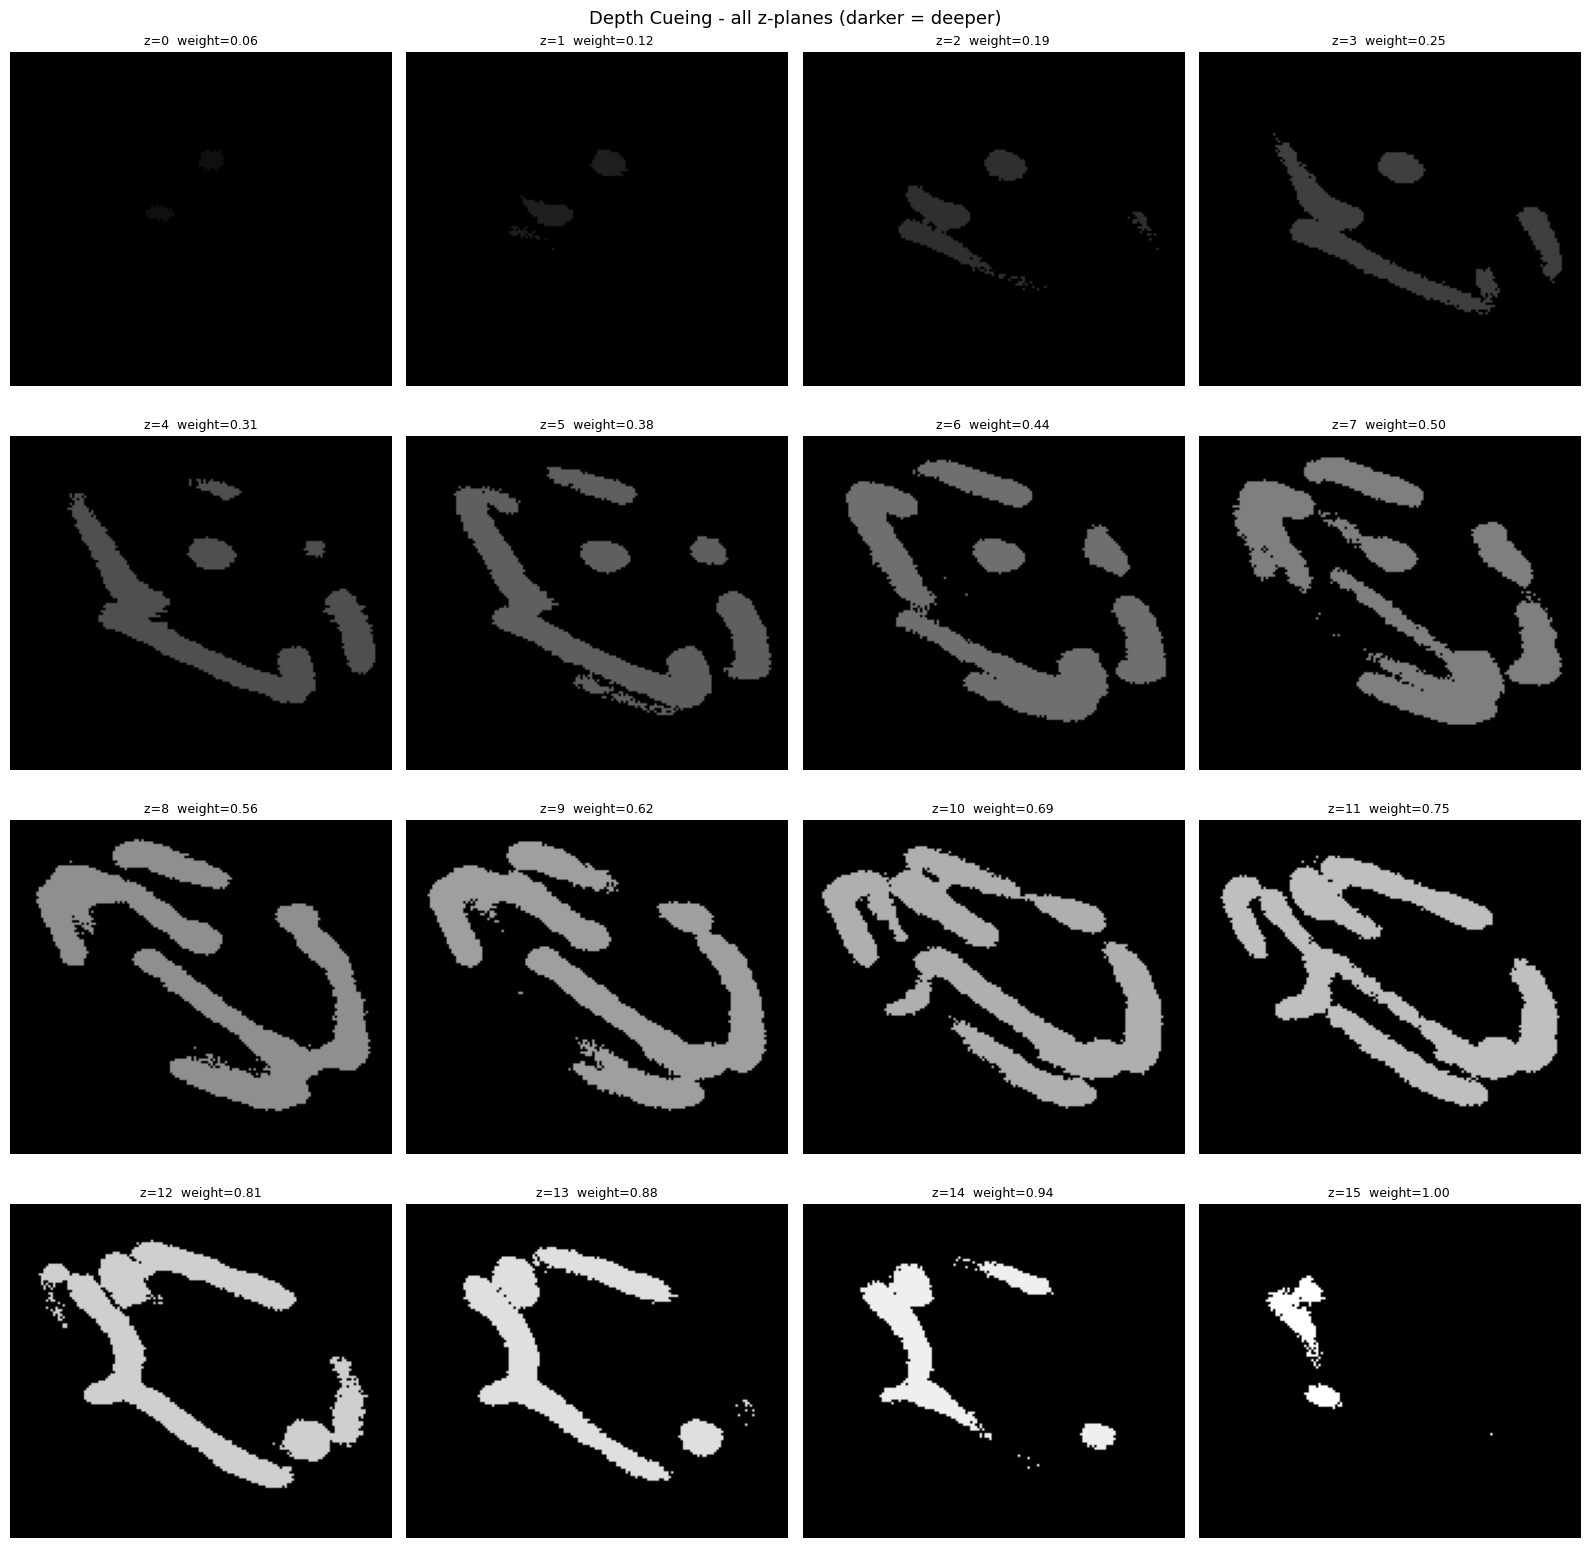

In [11]:
# ── Visualise: show all slices with their assigned brightness ──────────────────
n_z = depth_cued_image.shape[0]
cols = 4
rows = int(np.ceil(n_z / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for z in range(n_z):
    weight = (z + 1) / n_z
    axes[z].imshow(depth_cued_image[z], cmap='gray', vmin=0, vmax=255)
    axes[z].set_title(f"z={z}  weight={weight:.2f}", fontsize=9)
    axes[z].axis('off')

for j in range(n_z, len(axes)):
    axes[j].axis('off')

plt.suptitle("Depth Cueing - all z-planes (darker = deeper)", fontsize=13)
plt.tight_layout()
plt.savefig("depth_cueing_slices.png", dpi=150, bbox_inches='tight')
plt.show()

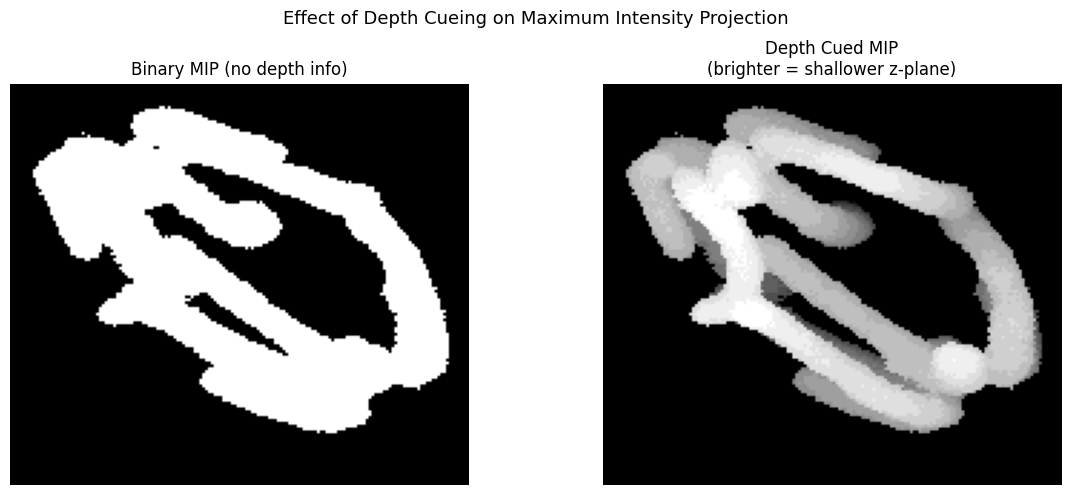

In [12]:
# ── Visualise: MIP of depth cued image (key figure for report) ────────────────
mip_dc  = np.max(depth_cued_image, axis=0)   # max projection → shows all depths
mip_bin = np.max(binary_np * 255, axis=0)    # binary MIP for comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(mip_bin, cmap='gray')
axes[0].set_title("Binary MIP (no depth info)")
axes[0].axis('off')
axes[1].imshow(mip_dc, cmap='gray')
axes[1].set_title("Depth Cued MIP\n(brighter = shallower z-plane)")
axes[1].axis('off')

plt.suptitle("Effect of Depth Cueing on Maximum Intensity Projection", fontsize=13)
plt.tight_layout()
plt.savefig("depth_cueing_mip.png", dpi=150)
plt.show()